# L16: Training Neural Networks

**Goal:** Train a neural network classifier, observe overfitting, and apply fixes.

**What you'll do:**
1. Load and prepare a dataset for classification
2. Train your first neural network
3. Plot training curves to monitor learning
4. Track train and validation loss together
5. See overfitting in action
6. Apply early stopping to prevent overfitting
7. Compare different network sizes
8. Design your own architecture

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

## 1. Load and Prepare the Data

We'll use the **Wine dataset** — a classic classification problem with 13 features and 3 classes. The three classes represent wines from three different **cultivators** (growers) in the same region of Italy. The task is to predict which cultivator produced a wine based on chemical measurements like alcohol content, color intensity, etc.

In [2]:
# Load the dataset
wine = load_wine()
X = wine.data    # shape: (178, 13)
y = wine.target  # 3 classes: 0, 1, 2

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", np.unique(y))
print()

# Show feature names
for i in range(len(wine.feature_names)):
    print(f"  Feature {i}: {wine.feature_names[i]}")

Number of samples: 178
Number of features: 13
Classes: [0 1 2]

  Feature 0: alcohol
  Feature 1: malic_acid
  Feature 2: ash
  Feature 3: alcalinity_of_ash
  Feature 4: magnesium
  Feature 5: total_phenols
  Feature 6: flavanoids
  Feature 7: nonflavanoid_phenols
  Feature 8: proanthocyanins
  Feature 9: color_intensity
  Feature 10: hue
  Feature 11: od280/od315_of_diluted_wines
  Feature 12: proline


### Train/Test Split and Scaling

Neural networks are sensitive to feature scales — a feature ranging from 0 to 1000 would dominate one ranging from 0 to 1. We use `StandardScaler` to put all features on the same scale (mean 0, standard deviation 1).

**Reminder: `StandardScaler`**
```python
scaler = StandardScaler()
scaler.fit(X_train)                # learn mean and std from training data
X_train = scaler.transform(X_train)  # apply to training data
X_test = scaler.transform(X_test)    # apply same transformation to test data
```

In [3]:
# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale features
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 124
Test samples: 54


## 2. Your First Neural Network

In sklearn, `MLPClassifier` handles the entire training loop for us: forward pass, backward pass (backpropagation), and weight updates.

### NEW: `MLPClassifier` — Multi-Layer Perceptron

```python
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(8,),   # one hidden layer with 8 neurons (tuple!)
    max_iter=200,              # maximum number of epochs
    random_state=42            # for reproducibility
)
model.fit(X_train, y_train)    # train the network

model.score(X, y)              # classification accuracy (fraction correct)
model.predict(X_new)           # predicted class labels
model.predict_proba(X_new)     # predicted probabilities for each class
model.loss_curve_              # list of loss values, one per epoch
model.n_iter_                  # number of epochs actually trained
```

**Note:** `hidden_layer_sizes` is a **tuple**. Write `(8,)` for one layer, `(128, 64)` for two layers.

In [4]:
### BEGIN SOLUTION
model = MLPClassifier(hidden_layer_sizes=(8,), max_iter=200, random_state=42)
model.fit(X_train, y_train)
### END SOLUTION

print(f"Training accuracy: {model.score(X_train, y_train):.3f}")
print(f"Number of epochs trained: {model.n_iter_}")

Training accuracy: 0.871
Number of epochs trained: 200


/Users/farzad/venvs/my_python3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


You'll see a `ConvergenceWarning` — this just means the network hadn't fully converged when it hit the 200-epoch limit. It's not an error; it's telling us the network could benefit from more training. We'll explore this with training curves next.

## 3. Plotting the Training Curve

The **training curve** (also called the **loss curve**) shows how the loss changes over epochs. It's the most important tool for diagnosing whether training is going well.

sklearn stores the loss at each epoch in `model.loss_curve_` after fitting.

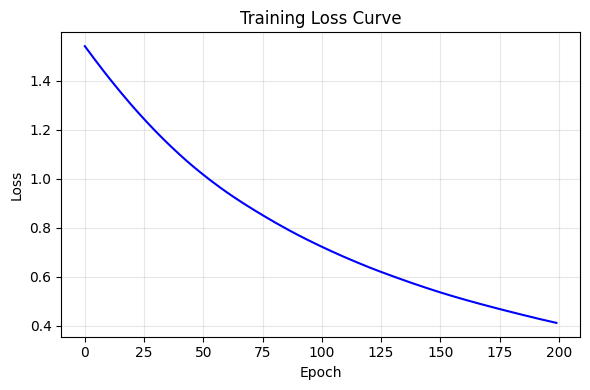

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(model.loss_curve_, color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The loss should decrease and eventually flatten out (plateau). If it's still going down at the end, we might benefit from more epochs.

## 4. Tracking Train and Validation Loss Together

To detect overfitting, we need to track **both** train loss and validation loss. We can do this by training the network one epoch at a time using `partial_fit()` and computing the loss ourselves after each epoch.

### NEW: `log_loss` — Cross-Entropy Loss

```python
from sklearn.metrics import log_loss

loss = log_loss(y_true, y_predicted_probabilities)
```

This is the loss function used for classification. Lower is better.

In [6]:
from sklearn.metrics import log_loss

def train_and_track(hidden_layer_sizes, X_train, y_train, X_val, y_val,
                    n_epochs=300, learning_rate_init=0.001, random_state=42):
    """
    Train an MLP one epoch at a time and record train/val loss at each epoch.
    Returns the fitted model and lists of train_losses, val_losses.
    """
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        random_state=random_state
    )

    classes = np.unique(y_train)
    train_losses = []
    val_losses = []

    for epoch in range(n_epochs):
        model.partial_fit(X_train, y_train, classes=classes)

        # Compute loss on train and validation sets
        train_proba = model.predict_proba(X_train)
        val_proba = model.predict_proba(X_val)
        train_losses.append(log_loss(y_train, train_proba))
        val_losses.append(log_loss(y_val, val_proba))

    return model, train_losses, val_losses

We need a separate validation set (carved out from the training data) to monitor overfitting during training. The test set stays untouched until the very end.

In [7]:
# Split the training data further into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

print("Train samples:", X_tr.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples (held out):", X_test.shape[0])

Train samples: 93
Validation samples: 31
Test samples (held out): 54


Now let's train a small network and plot both curves.

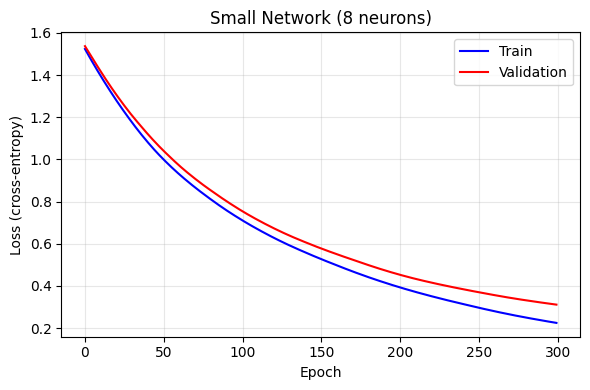

Final train accuracy: 0.935
Final val accuracy:   0.839


In [8]:
# Train a small network: 1 hidden layer with 8 neurons
model_small, train_losses, val_losses = train_and_track(
    hidden_layer_sizes=(8,),
    X_train=X_tr, y_train=y_tr,
    X_val=X_val, y_val=y_val,
    n_epochs=300
)

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train", color='blue')
plt.plot(val_losses, label="Validation", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss (cross-entropy)")
plt.title("Small Network (8 neurons)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train accuracy: {model_small.score(X_tr, y_tr):.3f}")
print(f"Final val accuracy:   {model_small.score(X_val, y_val):.3f}")

Both curves should go down together. This is a healthy training curve — the network is learning without overfitting much.

## 5. Overfitting in Action

Now let's train a **much larger** network (two hidden layers with 128 and 64 neurons) for many epochs. With only ~90 training samples and thousands of parameters, the network has enough capacity to **memorize** the training data.

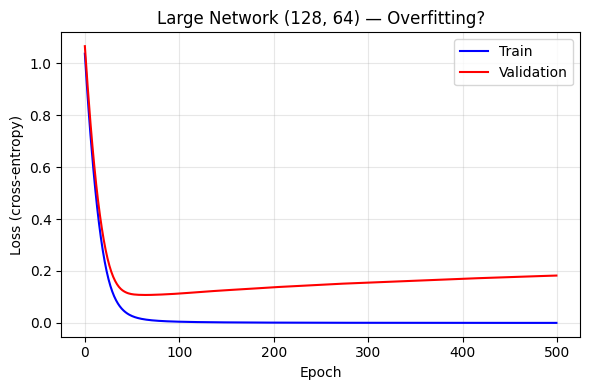

Final train accuracy: 1.000
Final val accuracy:   0.935


In [9]:
### BEGIN SOLUTION
model_large, train_losses_large, val_losses_large = train_and_track(
    hidden_layer_sizes=(128, 64),
    X_train=X_tr, y_train=y_tr,
    X_val=X_val, y_val=y_val,
    n_epochs=500
)
### END SOLUTION

plt.figure(figsize=(6, 4))
plt.plot(train_losses_large, label="Train", color='blue')
plt.plot(val_losses_large, label="Validation", color='red')
plt.xlabel("Epoch")
plt.ylabel("Loss (cross-entropy)")
plt.title("Large Network (128, 64) — Overfitting?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train accuracy: {model_large.score(X_tr, y_tr):.3f}")
print(f"Final val accuracy:   {model_large.score(X_val, y_val):.3f}")

Notice the classic overfitting pattern:
- **Train loss** keeps going down (toward zero)
- **Validation loss** stops improving and may start rising
- The **gap** between the two curves grows over time

The network is memorizing the training data rather than learning general patterns.

## 6. Fix 1: Early Stopping

**Early stopping** means we stop training when the validation loss stops improving. We "roll back" to the weights from the best epoch.

We already have the train and validation loss from the large network above. Let's find the **best epoch** — the one where validation loss was lowest — and see what happens if we stop there.

In [10]:
# Find the epoch with the lowest validation loss
best_epoch = 0
for i in range(len(val_losses_large)):
    if val_losses_large[i] < val_losses_large[best_epoch]:
        best_epoch = i

print(f"Best epoch: {best_epoch}")
print(f"Val loss at best epoch: {val_losses_large[best_epoch]:.4f}")
print(f"Val loss at final epoch: {val_losses_large[-1]:.4f}")

Best epoch: 65
Val loss at best epoch: 0.1077
Val loss at final epoch: 0.1824


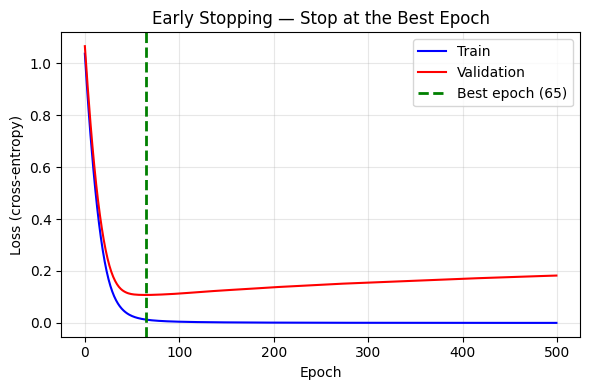

In [11]:
# Show where early stopping would have stopped
plt.figure(figsize=(6, 4))
plt.plot(train_losses_large, label="Train", color='blue')
plt.plot(val_losses_large, label="Validation", color='red')
plt.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2,
            label=f'Best epoch ({best_epoch})')
plt.xlabel("Epoch")
plt.ylabel("Loss (cross-entropy)")
plt.title("Early Stopping — Stop at the Best Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The green dashed line shows where we should have stopped. Everything to the right of it is wasted training that only made the model worse on new data.

In practice, we don't want to implement this manually every time. sklearn's `MLPClassifier` has built-in early stopping support.

### NEW: Early Stopping in `MLPClassifier`

```python
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    early_stopping=True,          # enable early stopping
    n_iter_no_change=10,          # patience: stop after 10 epochs with no improvement
    validation_fraction=0.25,     # use 25% of training data for validation
    max_iter=500,                 # upper limit on epochs
    random_state=42
)
model.fit(X_train, y_train)

model.best_validation_score_      # best validation accuracy seen during training
model.n_iter_                     # epoch where training actually stopped
```

When `early_stopping=True`, sklearn automatically splits off a validation set and stops when validation performance plateaus.

In [12]:
### BEGIN SOLUTION
model_early = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.25,
    max_iter=500,
    random_state=42
)
model_early.fit(X_train, y_train)
### END SOLUTION

print(f"Stopped after {model_early.n_iter_} epochs (out of 500 max)")
print(f"Best validation accuracy: {model_early.best_validation_score_:.3f}")

Stopped after 28 epochs (out of 500 max)
Best validation accuracy: 0.935


Early stopping let the large network train just long enough to learn the patterns, then stopped before it started memorizing. The final model uses the weights from the **best** epoch, not the last one.

**Note:** sklearn's early stopping monitors validation *accuracy* internally, while our manual tracking above used validation *loss*. Both measure essentially the same thing (is the model improving on held-out data?) — they just stop at slightly different epochs.

## 7. Fix 2: Changing Network Size

Another way to control overfitting is to adjust the **network capacity** — the number of layers and neurons. Let's compare three architectures on the same data.

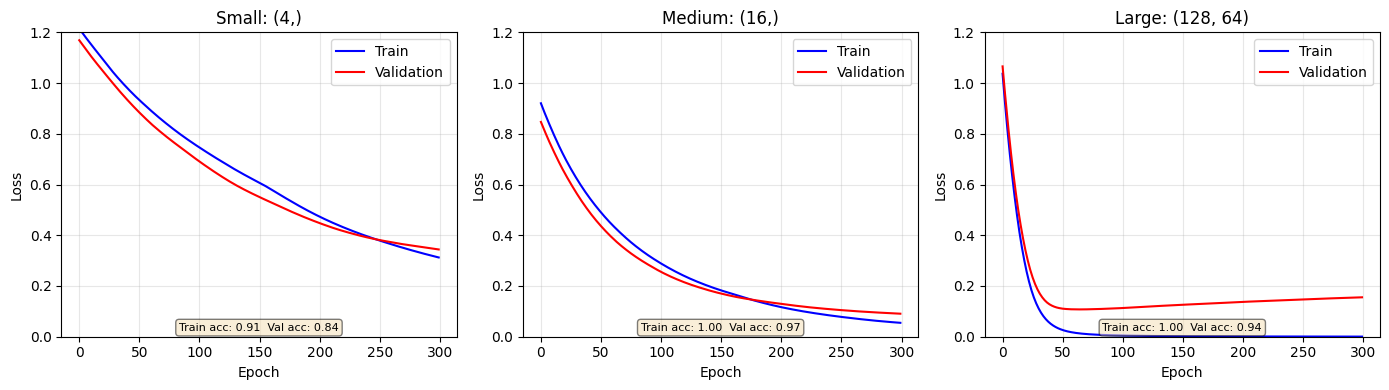

In [13]:
architectures = [
    ((4,),        "Small: (4,)"),
    ((16,),       "Medium: (16,)"),
    ((128, 64),   "Large: (128, 64)"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i in range(len(architectures)):
    hidden_sizes, label = architectures[i]
    ax = axes[i]

    model_i, train_loss_i, val_loss_i = train_and_track(
        hidden_layer_sizes=hidden_sizes,
        X_train=X_tr, y_train=y_tr,
        X_val=X_val, y_val=y_val,
        n_epochs=300
    )

    ax.plot(train_loss_i, label="Train", color='blue')
    ax.plot(val_loss_i, label="Validation", color='red')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0,1.2])

    train_acc = model_i.score(X_tr, y_tr)
    val_acc = model_i.score(X_val, y_val)
    ax.text(0.5, 0.02, f"Train acc: {train_acc:.2f}  Val acc: {val_acc:.2f}",
            transform=ax.transAxes, ha='center', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**What to look for:**
- **Small network (4 neurons):** Both losses stay relatively high — the network may not have enough capacity to learn the patterns (**underfitting**)
- **Medium network (16 neurons):** Both losses decrease and stay close — a good balance
- **Large network (128, 64):** Train loss drops to near zero, but val loss rises — the network is **overfitting**

**Note:** The accuracies shown are from the **final epoch** (epoch 300), not the best epoch. For the large network, these reflect the overfitted model — early stopping would give better validation accuracy.

## 8. Your Turn: Find a Good Architecture

Experiment with different architectures and training settings. Use **validation accuracy** to decide which model is best — do NOT look at test accuracy until you've made your final choice.

**Steps:**
1. Try different settings (change one thing at a time)
2. Compare **validation accuracy** to pick the best model
3. Only after you've decided, evaluate your final model on the **test set** once

**Note on data with `early_stopping=True`:** When you enable early stopping, sklearn internally holds out a fraction of the training data (default 25%) to monitor validation loss. Since we already split `X_train` into `X_tr` (93 samples) and `X_val` (31 samples), enabling early stopping further reduces the actual training data to about **70 samples**. Keep this in mind when interpreting results — the network is learning from less data than you might expect.

In [14]:
# Fresh train/val/test split (same as before, repeated here for convenience)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

### BEGIN SOLUTION
my_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    early_stopping=True,
    n_iter_no_change=10,
    max_iter=500,
    random_state=42
)
my_model.fit(X_tr, y_tr)
### END SOLUTION

print(f"Epochs trained: {my_model.n_iter_}")
print(f"Validation accuracy: {my_model.score(X_val, y_val):.3f}")

Epochs trained: 22
Validation accuracy: 0.935


Once you're happy with your validation accuracy, run the cell below **once** to see how your model does on the held-out test set. This is the number that tells you how well your model generalizes to truly unseen data.

In [15]:
# Final evaluation — run this only after you've chosen your best model
print(f"Test accuracy: {my_model.score(X_test, y_test):.3f}")

Test accuracy: 0.833


## Summary

| Concept | What it means |
|---------|---------------|
| **Training curve** | Plot of loss vs. epochs — your main diagnostic tool |
| **Overfitting** | Train loss low, val loss high — the network memorized the data |
| **Underfitting** | Both losses high — the network doesn't have enough capacity |
| **Good fit** | Both losses low with a small gap — the network generalizes well |
| **Early stopping** | Stop training when val loss stops improving; roll back to best weights |
| **Network size** | More neurons = more capacity; start small, add complexity only if underfitting |